# LaStBeRu × Rubin reference catalog

This notebook runs the large-catalog workflow in separate stages:

1. **TAP coverage:** counts individual images and summarizes seeing, limiting magnitude, exposure time, and epochs by band.
2. **Coadd properties:** optionally samples coadd quality maps only for targets with individual-image coverage.
3. **Cutouts:** optionally loads full coadds only for the prioritized targets.

Run the first stage over all targets before enabling the more expensive stages.

In [1]:
from pathlib import Path
from dataclasses import replace
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from target_selection import (
    load_reference_catalog_config,
    run_reference_coverage_catalog,
    enrich_reference_catalog_coadds,
    generate_reference_catalog_cutouts,
)

_repo_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (parent for parent in _repo_candidates if (parent / "configs" / "lastberu_dp2.toml").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Open this notebook from the target_selection repository or its notebooks/ directory.")

CONFIG_PATH = REPO_ROOT / "configs" / "lastberu_dp2.toml"
TARGET_LIMIT = 200  # Set None for all targets.
RUN_COVERAGE = True
RUN_COADD_DETECTION = True
RUN_COADD_PROPERTIES = False
RUN_CUTOUTS = True
REGENERATE_CUTOUTS = True  # Set False after the new layout has been generated.
MAX_CUTOUTS = 12

config = load_reference_catalog_config(CONFIG_PATH)
run_name = config.name if TARGET_LIMIT is None else f"{config.name}_preview_{TARGET_LIMIT}"
config = replace(
    config,
    name=run_name,
    target_limit=TARGET_LIMIT,
    max_cutouts=MAX_CUTOUTS,
    input_path=str(REPO_ROOT / config.input_path),
    output_dir=str(REPO_ROOT / config.output_dir),
    cache_dir=str(REPO_ROOT / config.cache_dir),
)
output_directory = Path(config.output_dir) / config.name
config

ReferenceCatalogConfig(input_path='/home/karennowo/target_selection/LaStBeRu_data/LaStBeRu_watchlist_LSST_grades.csv', name='lastberu_dp2_preview_200', output_dir='/home/karennowo/target_selection/outputs/catalog_enrichment', cache_dir='/home/karennowo/target_selection/outputs/_cache/reference_catalog', data_release='DP2', target_id_column='object_id', ra_column='ra', dec_column='dec', extra_info_column='extra_info', bands=('u', 'g', 'r', 'i', 'z', 'y'), property_maps=('maglim', 'psf_size', 'exposure_time', 'sky_noise'), coadd_skymap='lsst_cells_v2', coadd_pixel_scale_arcsec=0.2, partial_property_map_reads=True, visit_query_scope='coadd', tap_tile_nside=64, tap_max_workers=2, tap_timeout_seconds=7200, detector_search_radius_deg=0.35, target_limit=200, reuse_cache=True, generate_cutouts=True, max_cutouts=12, cutout_size_arcsec=20.0, cutout_grades=('A', 'B', 'C', 'D', 'E'), cutout_bands=('u', 'g', 'r', 'i', 'z', 'y'), quality_weights={'depth': 0.5, 'seeing': 0.35, 'band_coverage': 0.15},

## 1. TAP coverage and individual-image summaries

This is the fast first pass. It does not initialize Butler and does not read coadd maps.

In [2]:
coverage_path = output_directory / "coverage_catalog.csv"
if RUN_COVERAGE:
    coverage_catalog = run_reference_coverage_catalog(config)
elif coverage_path.exists():
    coverage_catalog = pd.read_csv(coverage_path)
else:
    raise FileNotFoundError(f"No coverage catalog at {coverage_path}. Set RUN_COVERAGE=True first.")

print(f"Coverage catalog: {len(coverage_catalog):,} targets")
coverage_catalog.head()

Visit tiles: 100%|██████████| 88/88 [00:00<00:00, 153.32tile/s]

Visit coverage: 88 spatial tiles, 200 targets, 696 target-band rows


Coverage catalog: /home/karennowo/target_selection/outputs/catalog_enrichment/lastberu_dp2_preview_200/coverage_catalog.csv
Coverage catalog: 200 targets


,object_id,ra,dec,type_label,original_source,redshift,redshift_error,redshift_label,extra_info,target_id,...,visit_last_mjd_i,visit_last_mjd_r,visit_last_mjd_u,visit_last_mjd_y,visit_last_mjd_z,n_images_total,visit_bands,visit_query_status,visit_query_error,visit_coverage_queried
0,LaStBeRu_J000001.1-350334.9,0.00471,-35.05971,Candidate SL system,Gioia et al. (1990) - doi:10.1086/191426,0.508000,-1.00000,NaN,"vetting_grade=nan,vetting_grade_survey=nan,Ori...",LaStBeRu_J000001.1-350334.9,...,61002.074832,NaN,NaN,NaN,NaN,10,"g,i",cache,,True
1,LaStBeRu_J000001.2+051908.6,0.00504,5.31906,Candidate SL system,Lopes et al. (2004) - doi:10.1086/423038,0.850000,0.33321,photometric,"vetting_grade=E,vetting_grade_survey=Legacy,Or...",LaStBeRu_J000001.2+051908.6,...,60877.307573,60879.339351,NaN,NaN,60867.318089,18,"g,r,i,z",cache,,True
2,LaStBeRu_J000002.2+085518.4,0.00925,8.92179,Candidate SL system,Lopes et al. (2004) - doi:10.1086/423038,-1.000000,-1.00000,NaN,"vetting_grade=E,vetting_grade_survey=Legacy,Or...",LaStBeRu_J000002.2+085518.4,...,60868.319324,60876.282115,NaN,NaN,60866.313003,18,"g,r,i,z",cache,,True
3,LaStBeRu_J000006.0+081629.7,0.02512,8.27492,Candidate SL system,Lopes et al. (2004) - doi:10.1086/423038,-1.000000,-1.00000,NaN,"vetting_grade=E,vetting_grade_survey=Legacy,Or...",LaStBeRu_J000006.0+081629.7,...,60877.307573,60877.283376,NaN,NaN,60869.319762,17,"g,r,i,z",cache,,True
4,LaStBeRu_J000006.1+213829.4,0.02542,21.64150,Candidate SL system,Huang et al. (2021) - arXiv:2005.04730,0.502973,-1.00000,spectroscopic,"vetting_grade=D,vetting_grade_survey=Legacy,Or...",LaStBeRu_J000006.1+213829.4,...,NaN,NaN,NaN,NaN,NaN,0,,cache,,True


## Coverage summary

`n_images_<band>` counts unique target/detector visit rows. The seeing and `mag_lim` columns are medians of the corresponding individual-image values.

In [3]:
bands = tuple(config.bands)
summary_rows = []
for band in bands:
    count_col = f"n_images_{band}"
    seeing_col = f"visit_seeing_mean_arcsec_{band}"
    maglim_col = f"visit_maglim_mean_{band}"
    counts = pd.to_numeric(coverage_catalog.get(count_col), errors="coerce").fillna(0)
    summary_rows.append({
        "band": band,
        "targets_with_images": int(counts.gt(0).sum()),
        "median_images_per_target": float(counts[counts.gt(0)].median()) if counts.gt(0).any() else 0.0,
        "median_seeing_arcsec": float(pd.to_numeric(coverage_catalog.get(seeing_col), errors="coerce").median()),
        "median_visit_maglim": float(pd.to_numeric(coverage_catalog.get(maglim_col), errors="coerce").median()),
    })
coverage_summary = pd.DataFrame(summary_rows)
print(f"Targets without images in any band: {int(pd.to_numeric(coverage_catalog['n_images_total'], errors='coerce').fillna(0).le(0).sum()):,}")
display(coverage_summary)
display(coverage_catalog[["target_id", "n_images_total", "visit_bands", "visit_query_status"]].head(20))

Targets without images in any band: 20


,band,targets_with_images,median_images_per_target,median_seeing_arcsec,median_visit_maglim
0,u,57,1.0,1.281354,23.601300
1,g,153,4.0,1.077279,24.494980
2,r,118,5.0,1.185386,23.670379
3,i,176,5.0,1.230362,22.877577
4,z,117,5.0,1.159518,22.486000
5,y,75,3.0,1.420285,21.527667


,target_id,n_images_total,visit_bands,visit_query_status
0,LaStBeRu_J000001.1-350334.9,10,"g,i",cache
1,LaStBeRu_J000001.2+051908.6,18,"g,r,i,z",cache
2,LaStBeRu_J000002.2+085518.4,18,"g,r,i,z",cache
3,LaStBeRu_J000006.0+081629.7,17,"g,r,i,z",cache
4,LaStBeRu_J000006.1+213829.4,0,,cache
5,LaStBeRu_J000006.9-633539.7,4,i,cache
6,LaStBeRu_J000007.1+081627.8,17,"g,r,i,z",cache
7,LaStBeRu_J000007.4-334059.0,3,"g,i",cache
8,LaStBeRu_J000008.5+022658.0,34,"u,g,r,i,z,y",cache
9,LaStBeRu_J000008.9+211702.8,0,,cache


## 2. Direct coadd detection and optional coadd-property enrichment

This stage queries Butler directly for real coadd datasets at the target positions. It does not use HealSparse maps to decide whether a coadd exists. Set `RUN_COADD_PROPERTIES=True` only if you also want optional coadd quality-map values; those maps are sampled only for targets with a direct coadd match.


In [4]:
reference_catalog_path = output_directory / "reference_catalog.csv"
if RUN_COADD_DETECTION:
    catalog = enrich_reference_catalog_coadds(
        config, coverage_catalog, sample_properties=RUN_COADD_PROPERTIES
    )
elif reference_catalog_path.exists():
    catalog = pd.read_csv(reference_catalog_path)
else:
    raise FileNotFoundError(
        f"No enriched catalog at {reference_catalog_path}. "
        "Set RUN_COADD_DETECTION=True first."
    )

coadd_summary = pd.DataFrame({
    "metric": ["targets", "with individual-image coverage", "with direct coadd", "cutout candidates"],
    "value": [
        len(catalog),
        int(pd.to_numeric(catalog.get("n_images_total"), errors="coerce").fillna(0).gt(0).sum()),
        int(catalog.get("has_coadd", pd.Series(False, index=catalog.index)).fillna(False).sum()),
        int(catalog.get("cutout_eligible", pd.Series(False, index=catalog.index)).fillna(False).sum()),
    ],
})
display(coadd_summary)
display(catalog[["target_id", "n_images_total", "has_coadd", "coadd_n_bands", "coadd_bands"]].head(20))


Direct coadd coverage: 100%|██████████| 180/180 [00:08<00:00, 20.98target/s]

Direct coadd coverage: /home/karennowo/target_selection/outputs/_cache/reference_catalog/DP2/bbd258778b39f52bcd1f/direct_coadd_coverage.csv



/home/karennowo/target_selection/target_selection/reference_catalog.py:1138: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result["has_coadd"] = result["has_coadd"].fillna(False).astype(bool)


,metric,value
0,targets,200
1,with individual-image coverage,180
2,with direct coadd,120
3,cutout candidates,104


,target_id,n_images_total,has_coadd,coadd_n_bands,coadd_bands
0,LaStBeRu_J000001.1-350334.9,10,False,0,
1,LaStBeRu_J000001.2+051908.6,18,True,4,"g,i,r,z"
2,LaStBeRu_J000002.2+085518.4,18,True,4,"g,i,r,z"
3,LaStBeRu_J000006.0+081629.7,17,True,4,"g,i,r,z"
4,LaStBeRu_J000006.1+213829.4,0,False,0,
5,LaStBeRu_J000006.9-633539.7,4,False,0,
6,LaStBeRu_J000007.1+081627.8,17,True,4,"g,i,r,z"
7,LaStBeRu_J000007.4-334059.0,3,False,0,
8,LaStBeRu_J000008.5+022658.0,34,True,6,"g,i,r,u,y,z"
9,LaStBeRu_J000008.9+211702.8,0,False,0,


## 3. Optional prioritized coadd cutouts

Full coadds are loaded only for the selected cutout budget.

Coadd cutouts: 100%|██████████| 12/12 [03:09<00:00, 15.78s/target]


,targets
status,
outside_cutout_budget,92
no_coadd,80
grade_not_selected,16
generated,12


Rank 1 — LaStBeRu_J000020.8-002051.0


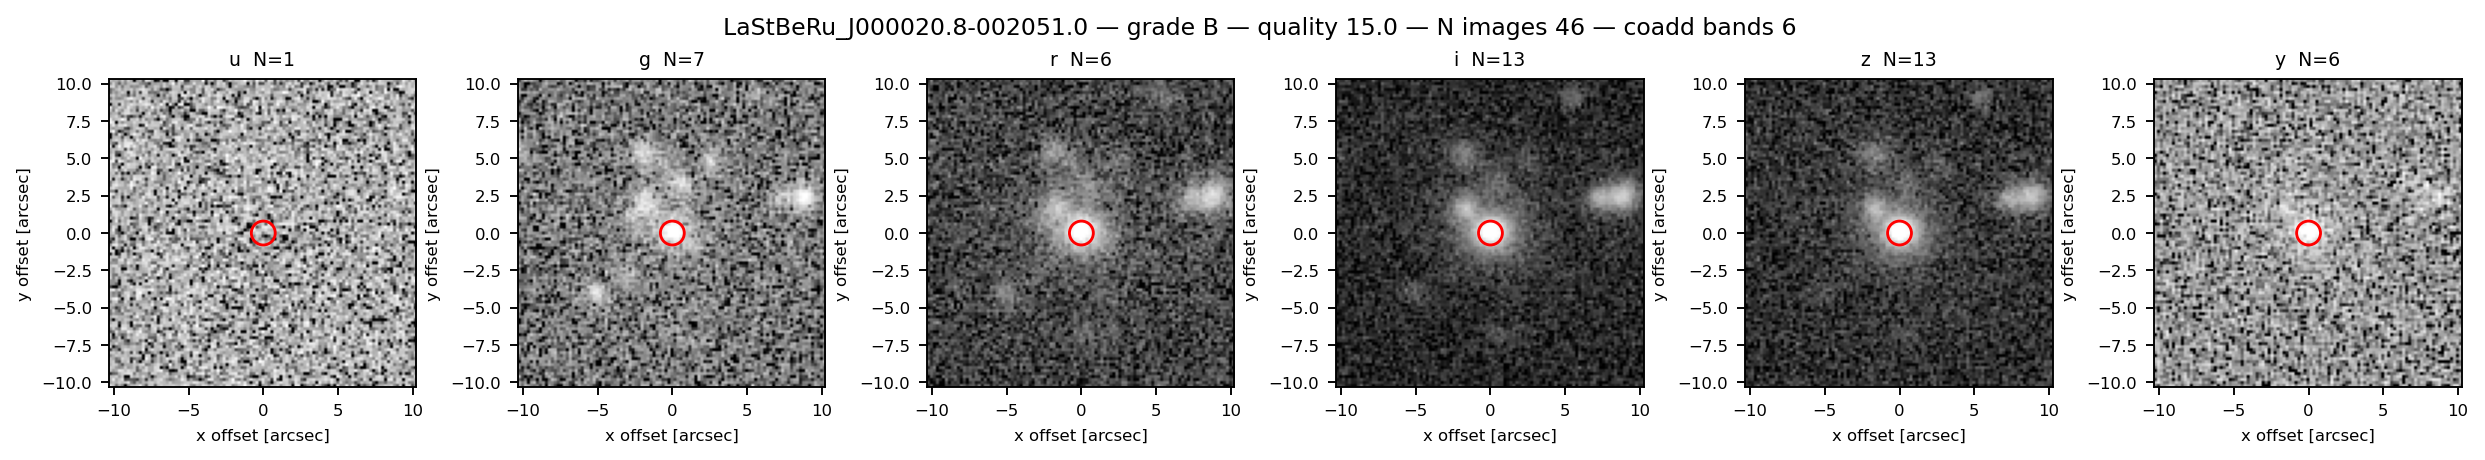

Rank 2 — LaStBeRu_J000051.8-002936.6


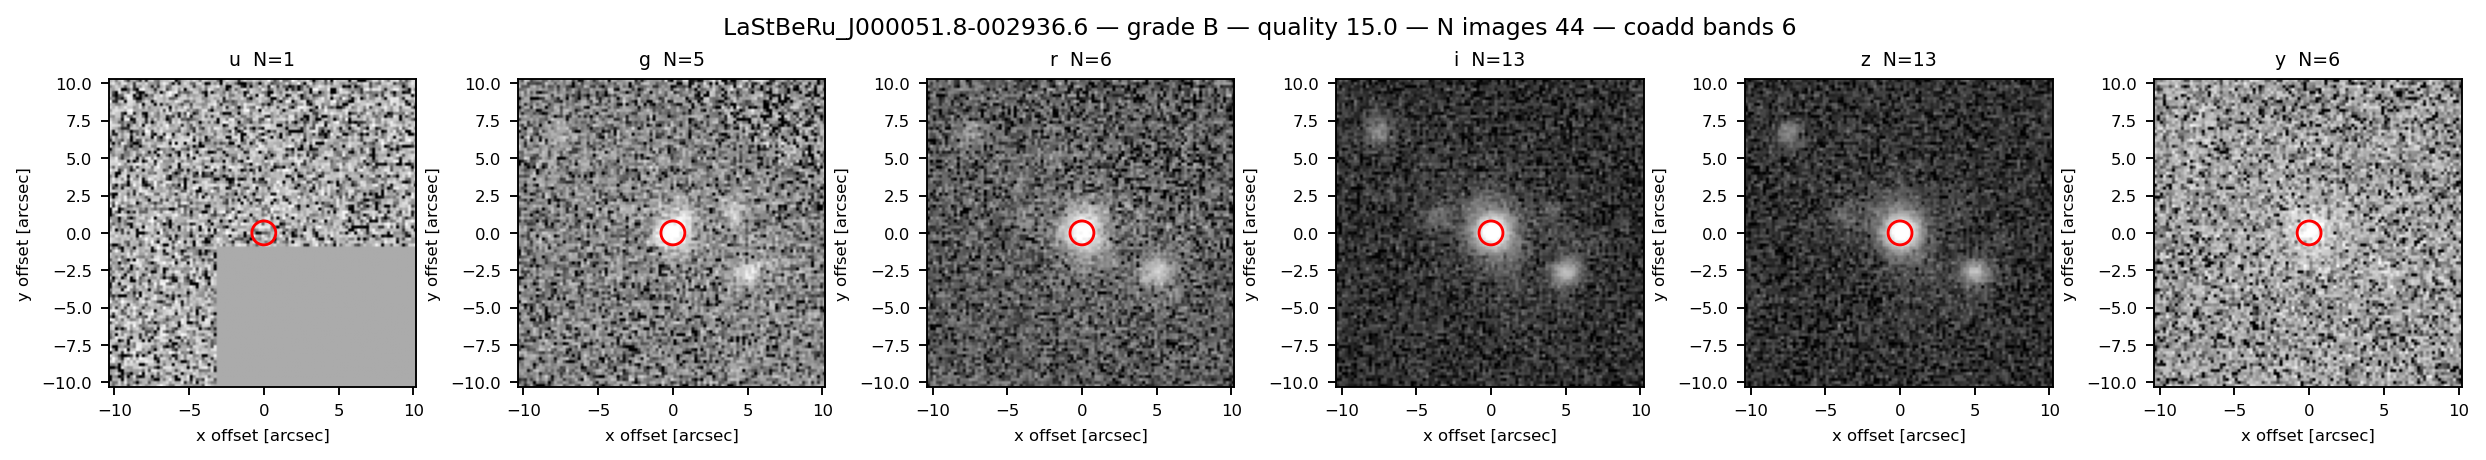

Rank 3 — LaStBeRu_J000313.1+005425.2


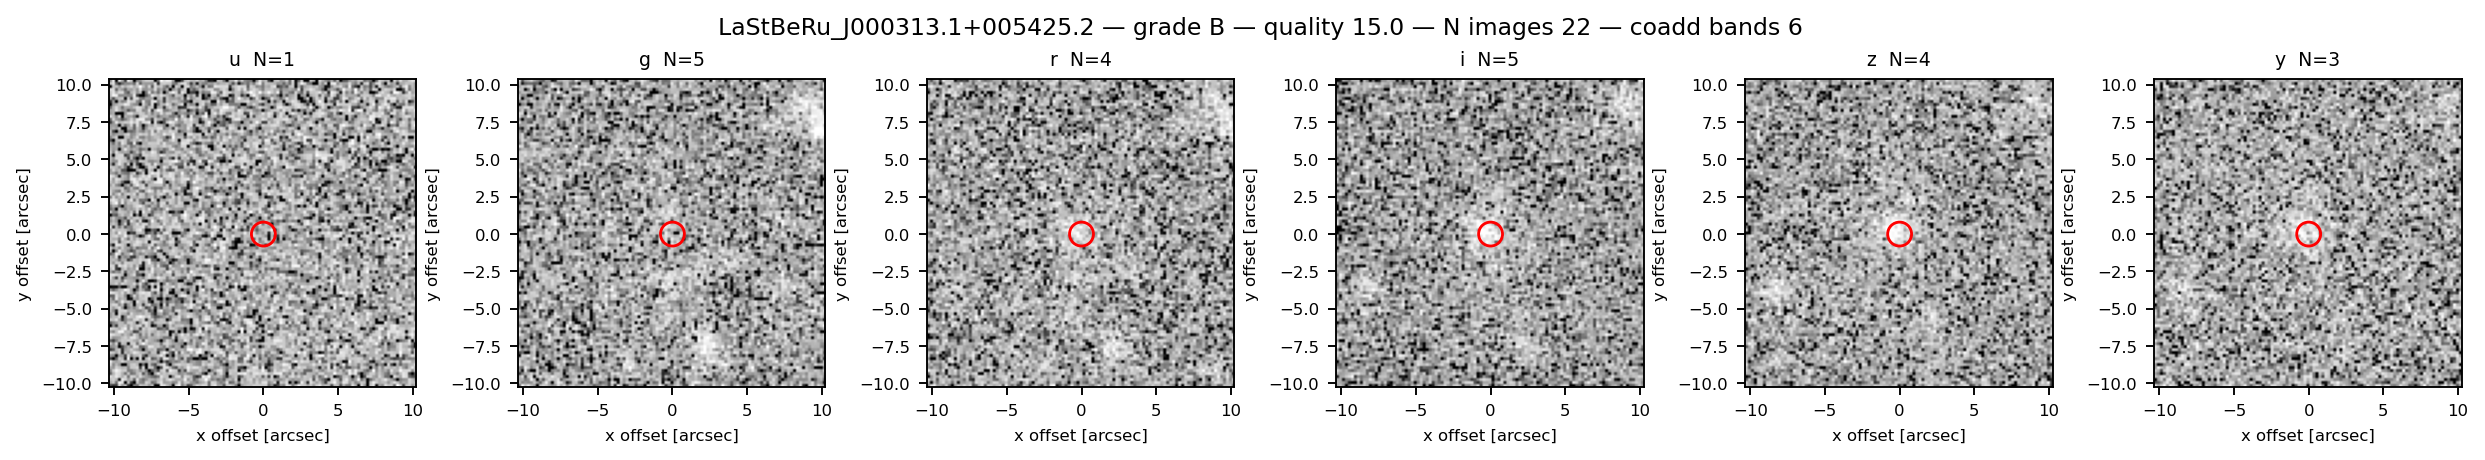

Rank 4 — LaStBeRu_J000451.8-010317.4


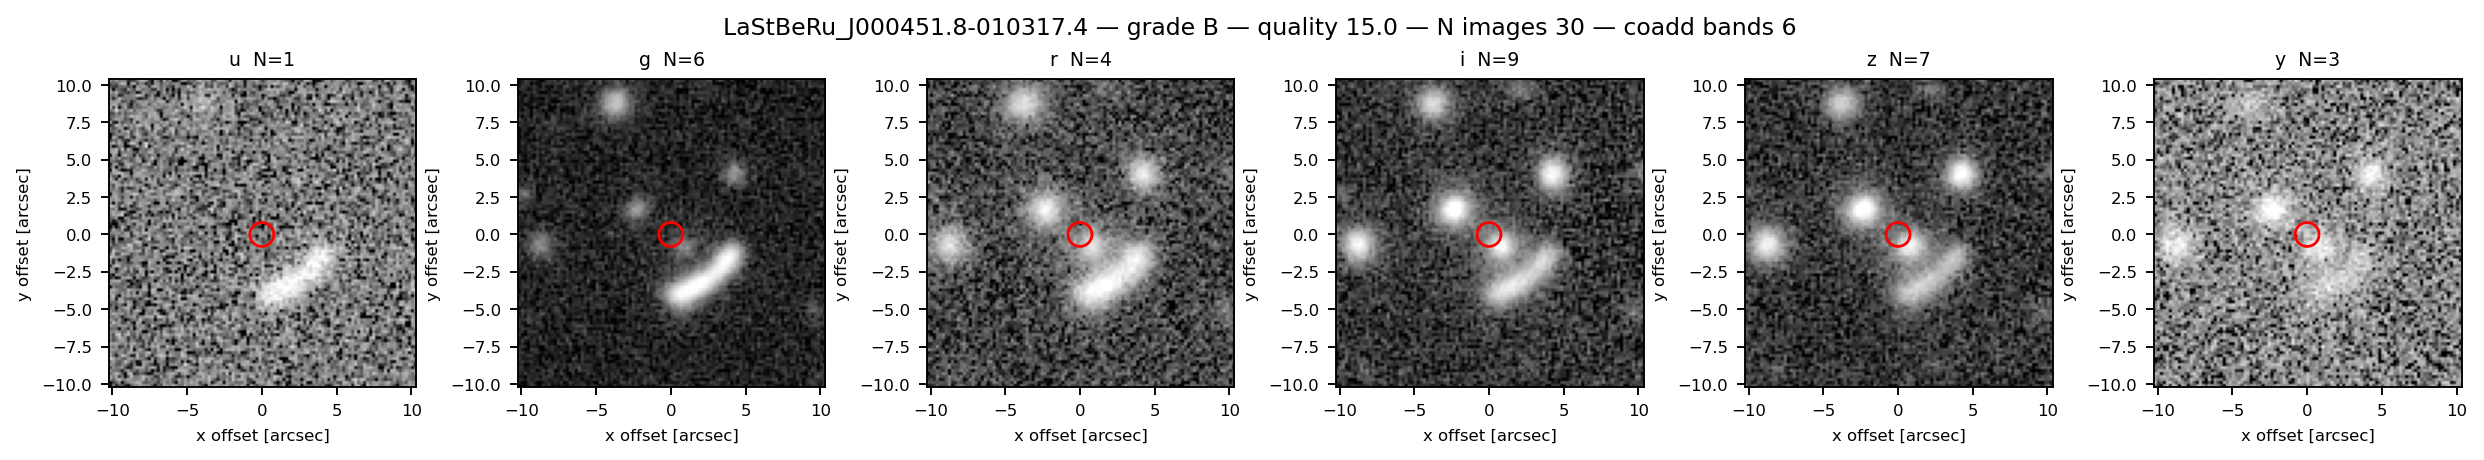

Rank 5 — LaStBeRu_J000451.9-010316.2


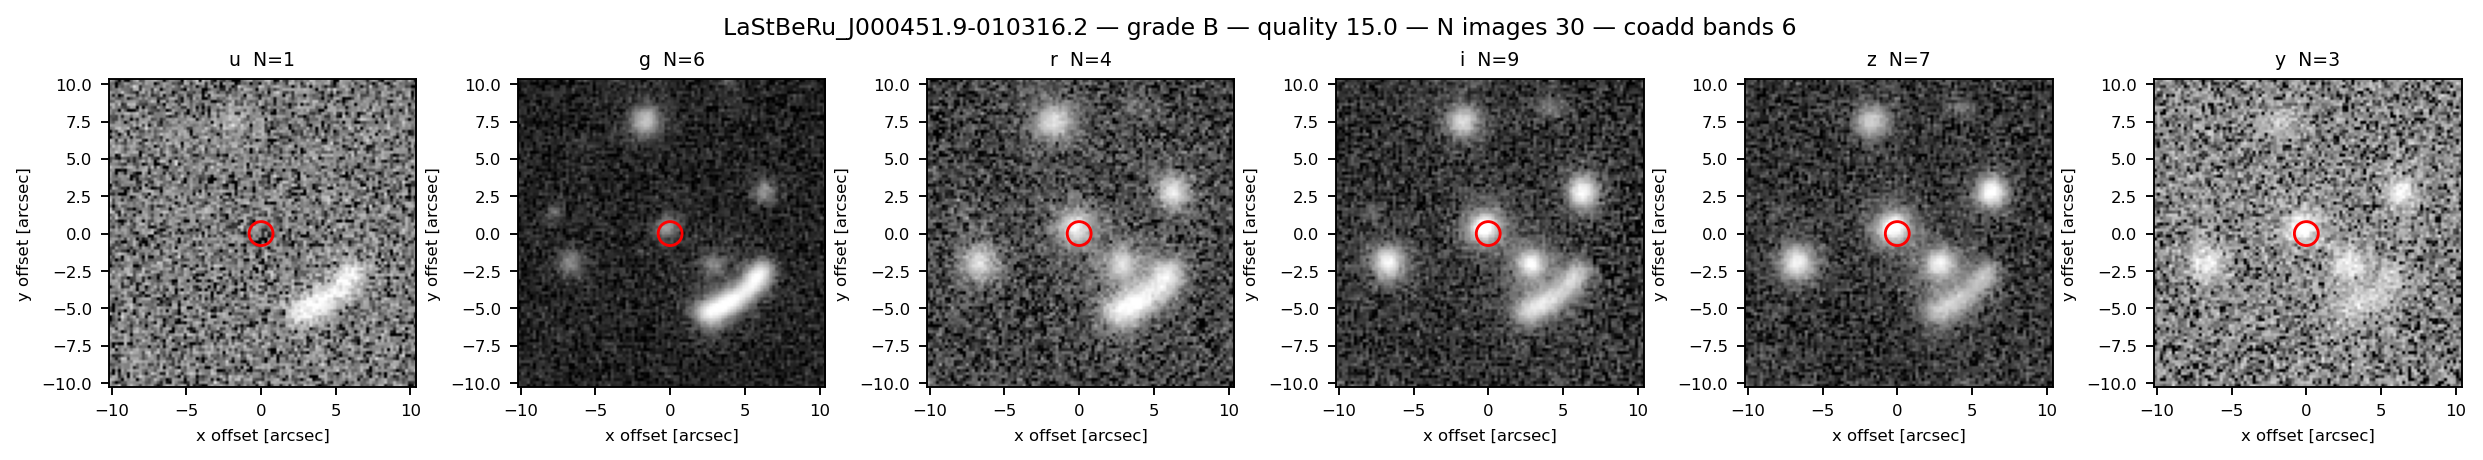

Rank 6 — LaStBeRu_J000018.9+001617.7


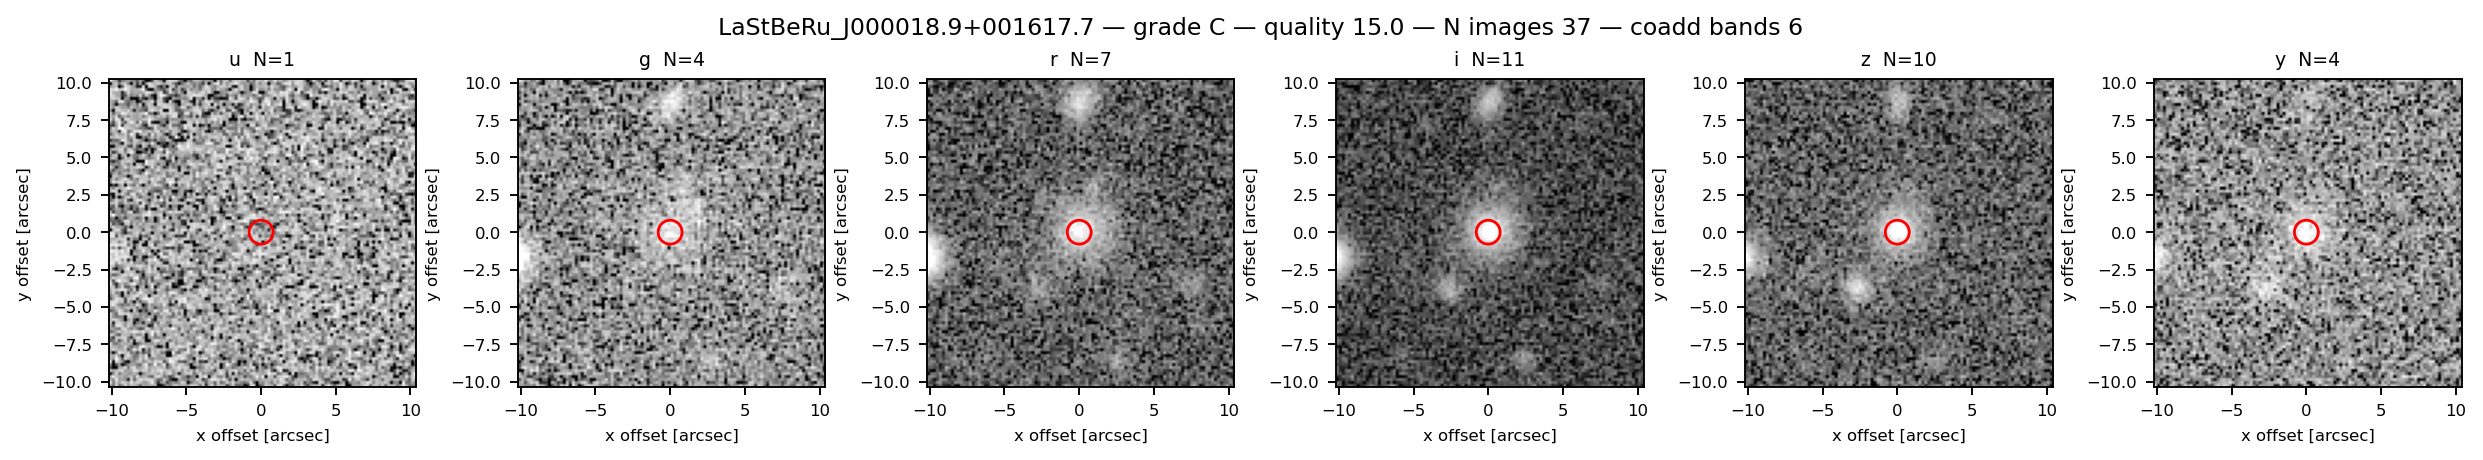

Rank 7 — LaStBeRu_J000025.5-035721.1


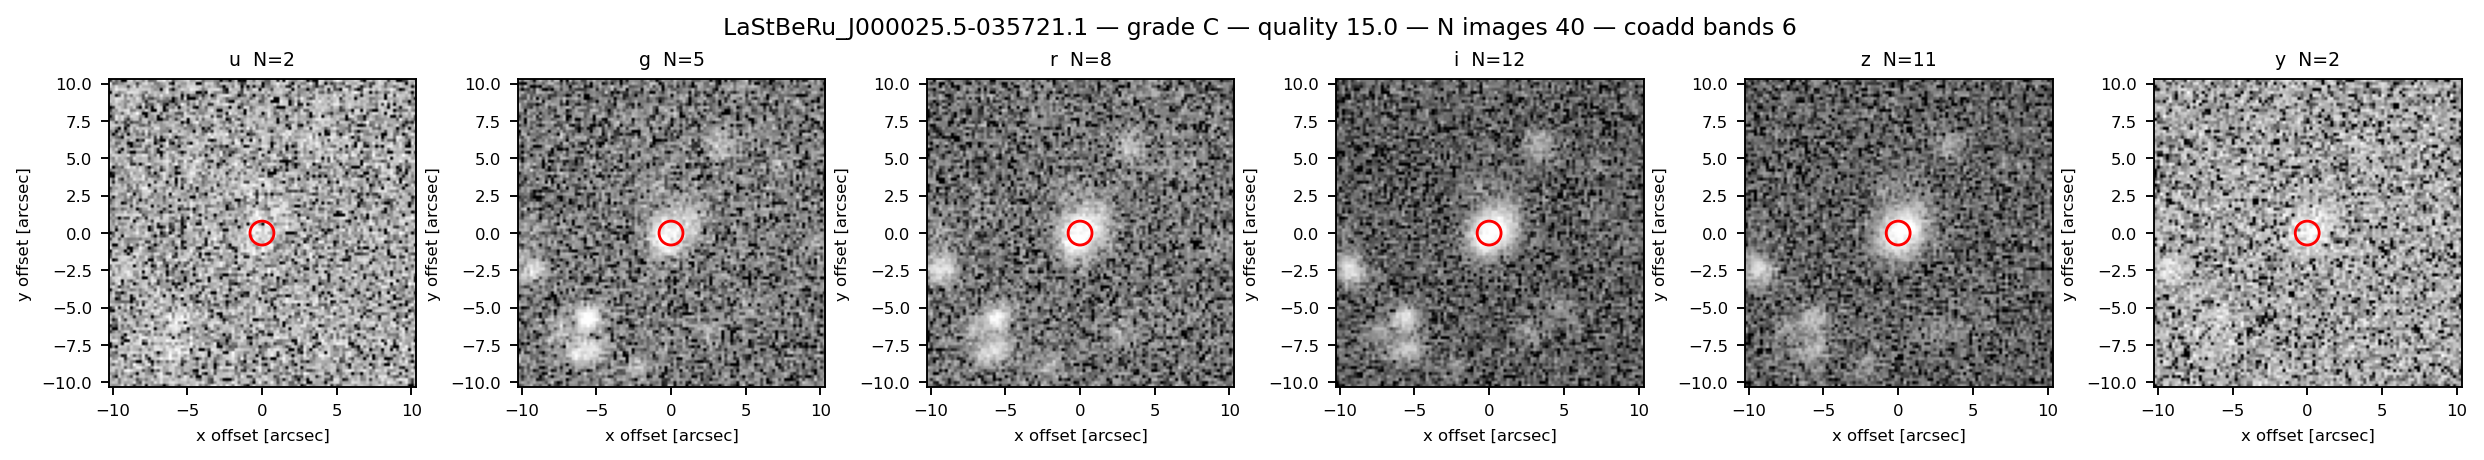

Rank 8 — LaStBeRu_J000106.5+010329.8


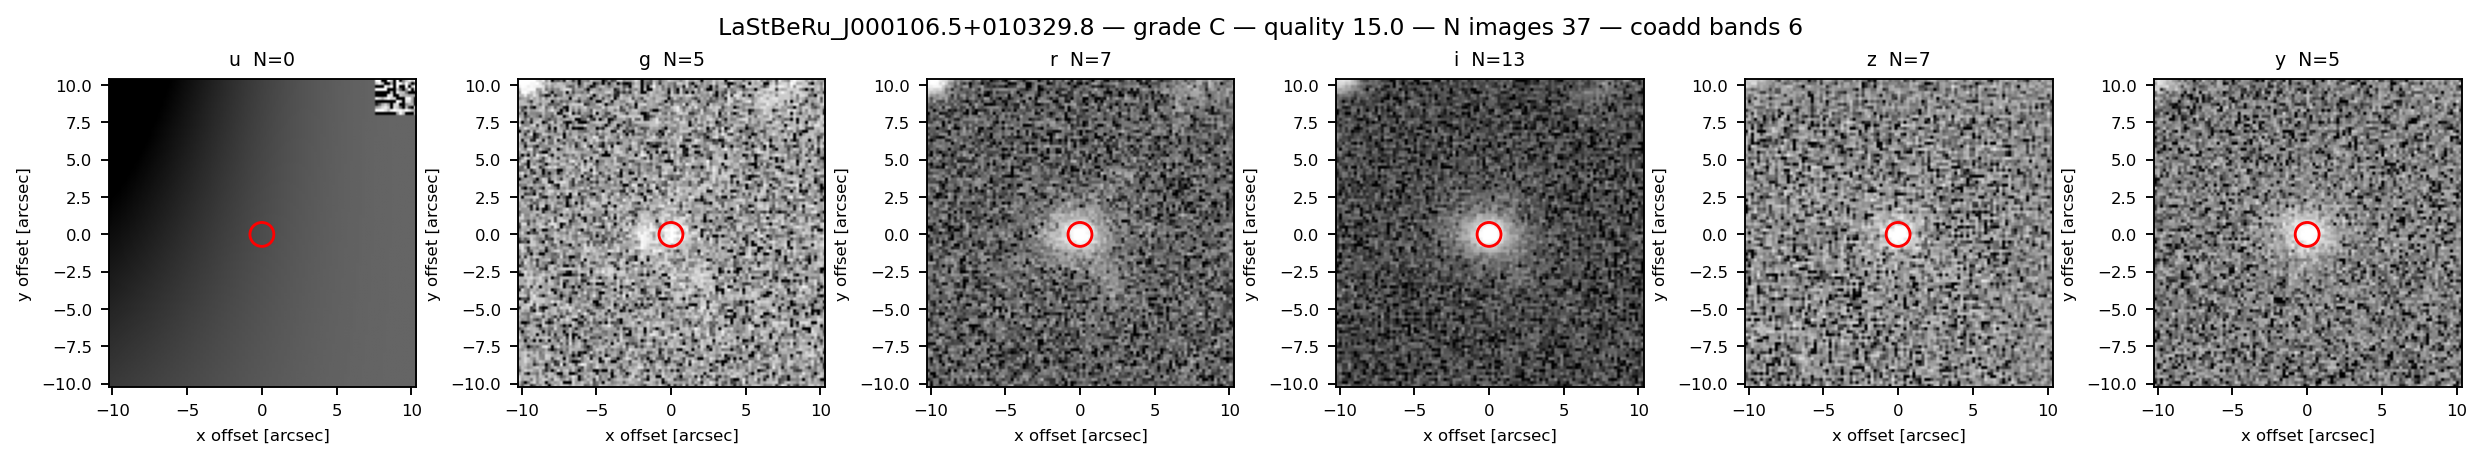

Rank 9 — LaStBeRu_J000114.5+001619.7


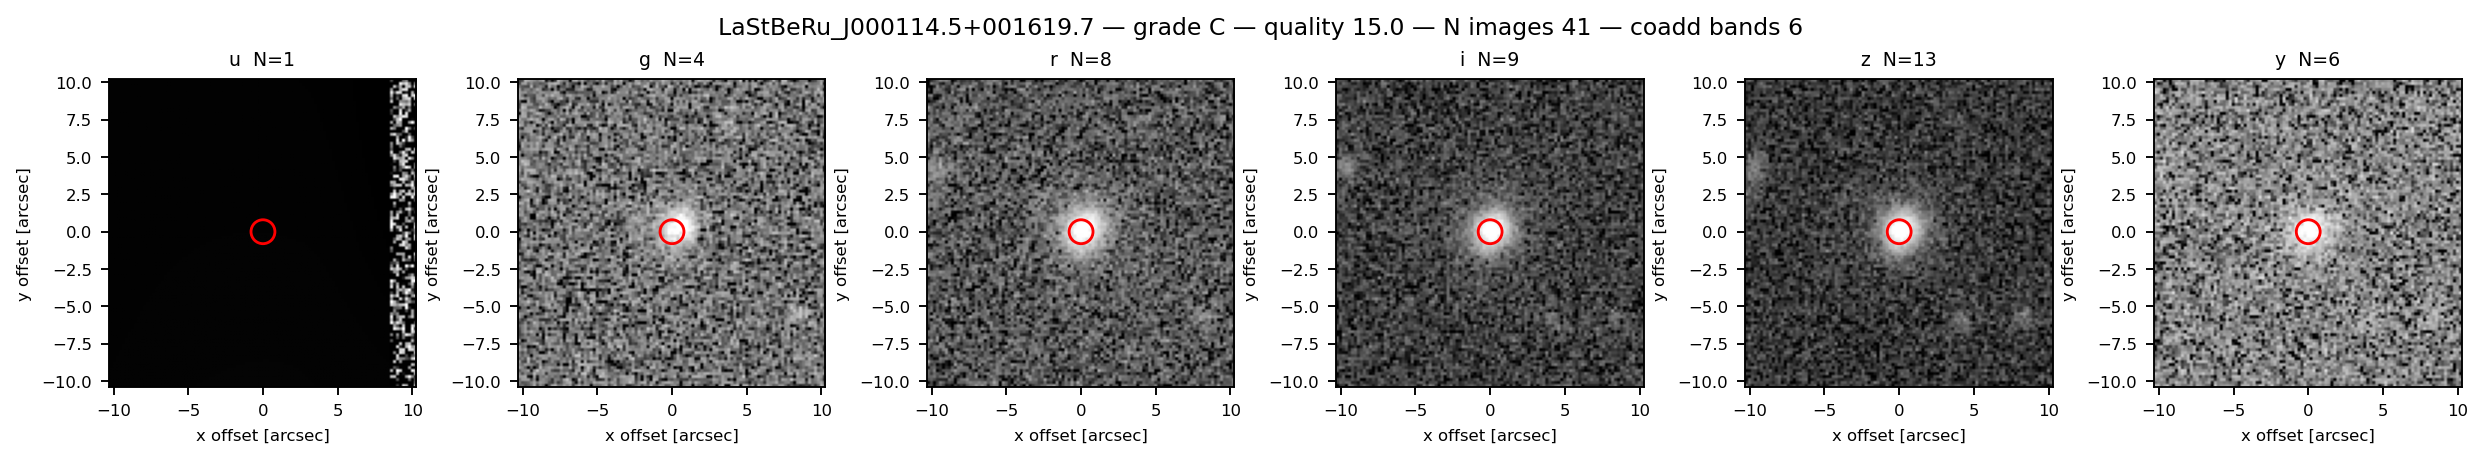

Rank 10 — LaStBeRu_J000129.6-000241.6


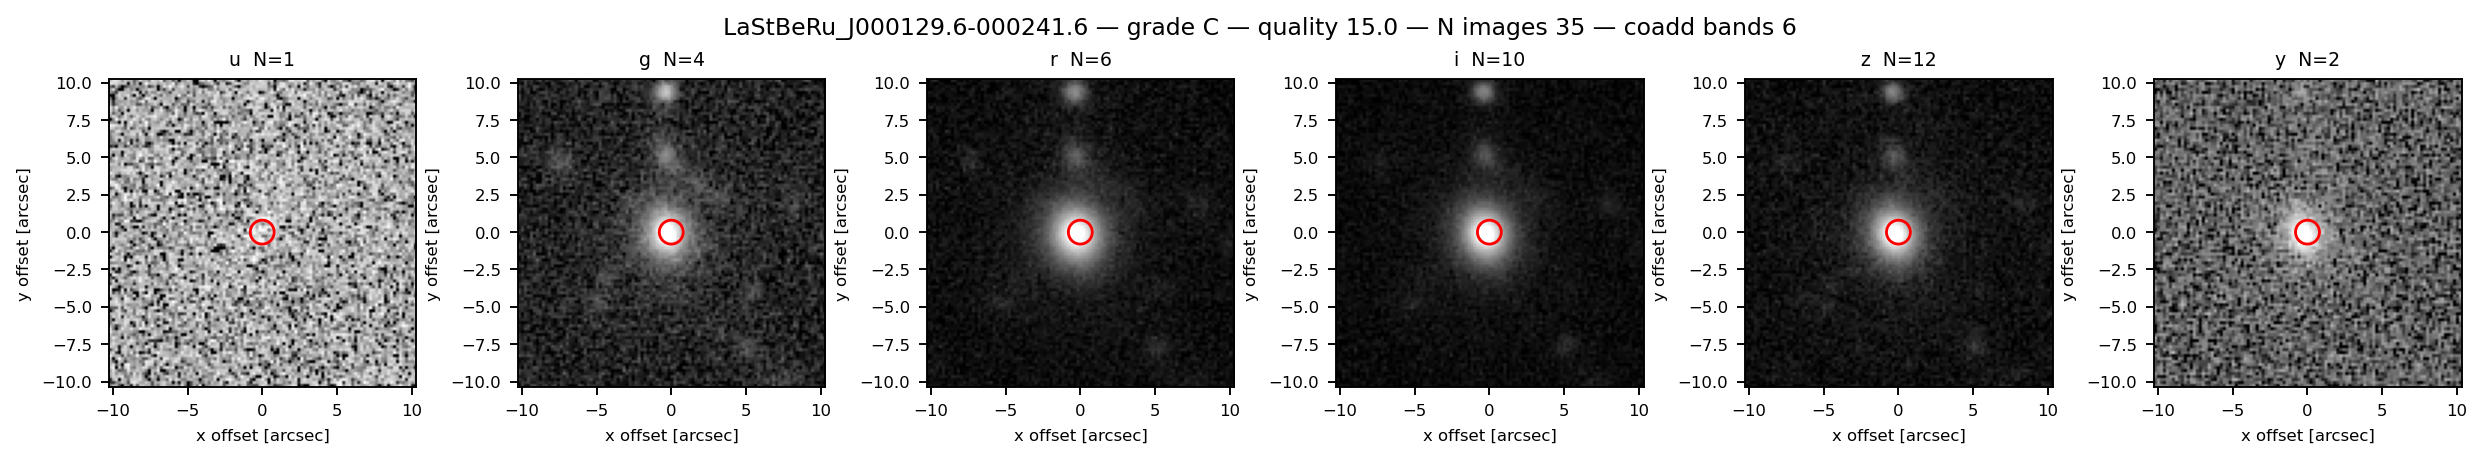

Rank 11 — LaStBeRu_J000241.1+024852.8


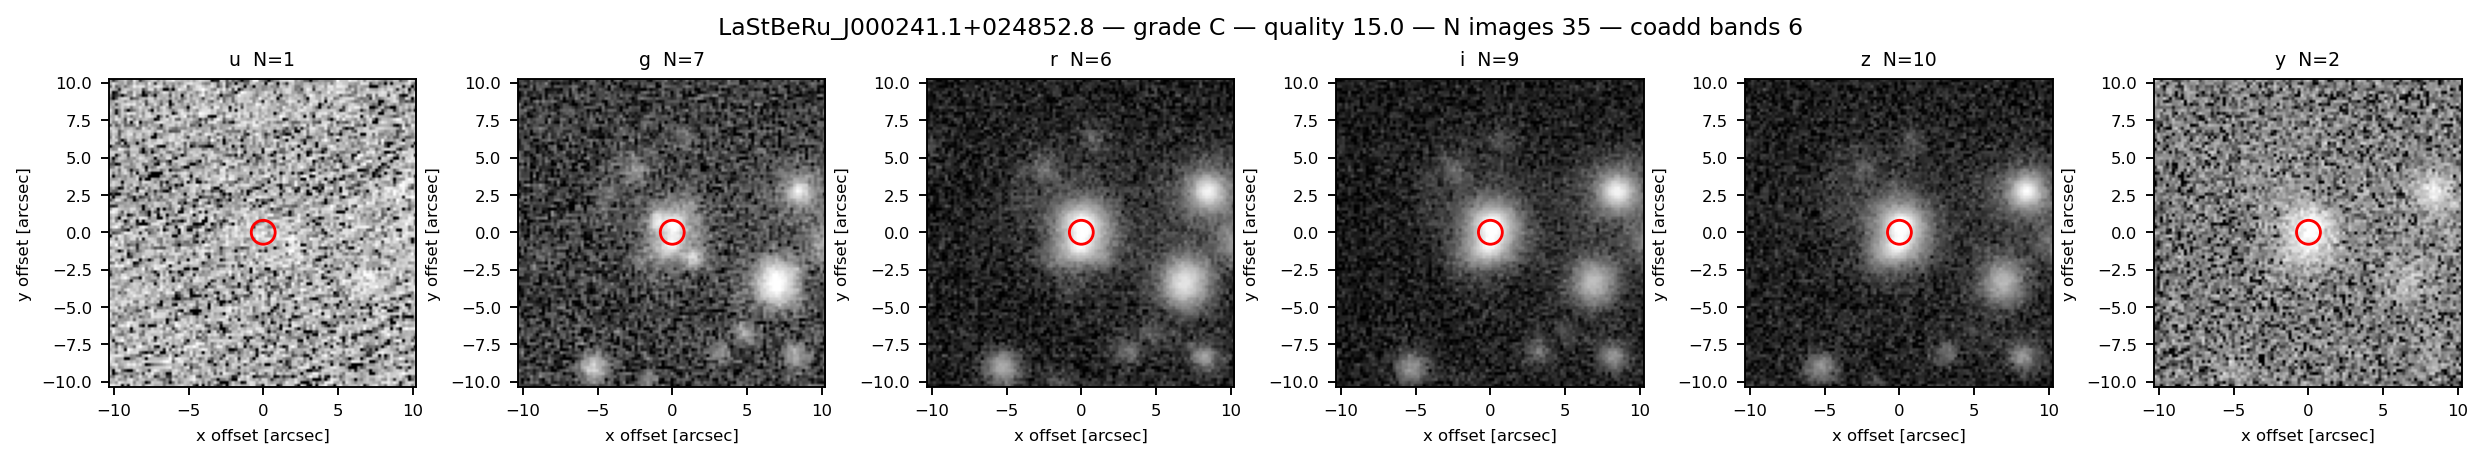

Rank 12 — LaStBeRu_J000241.1+024853.2


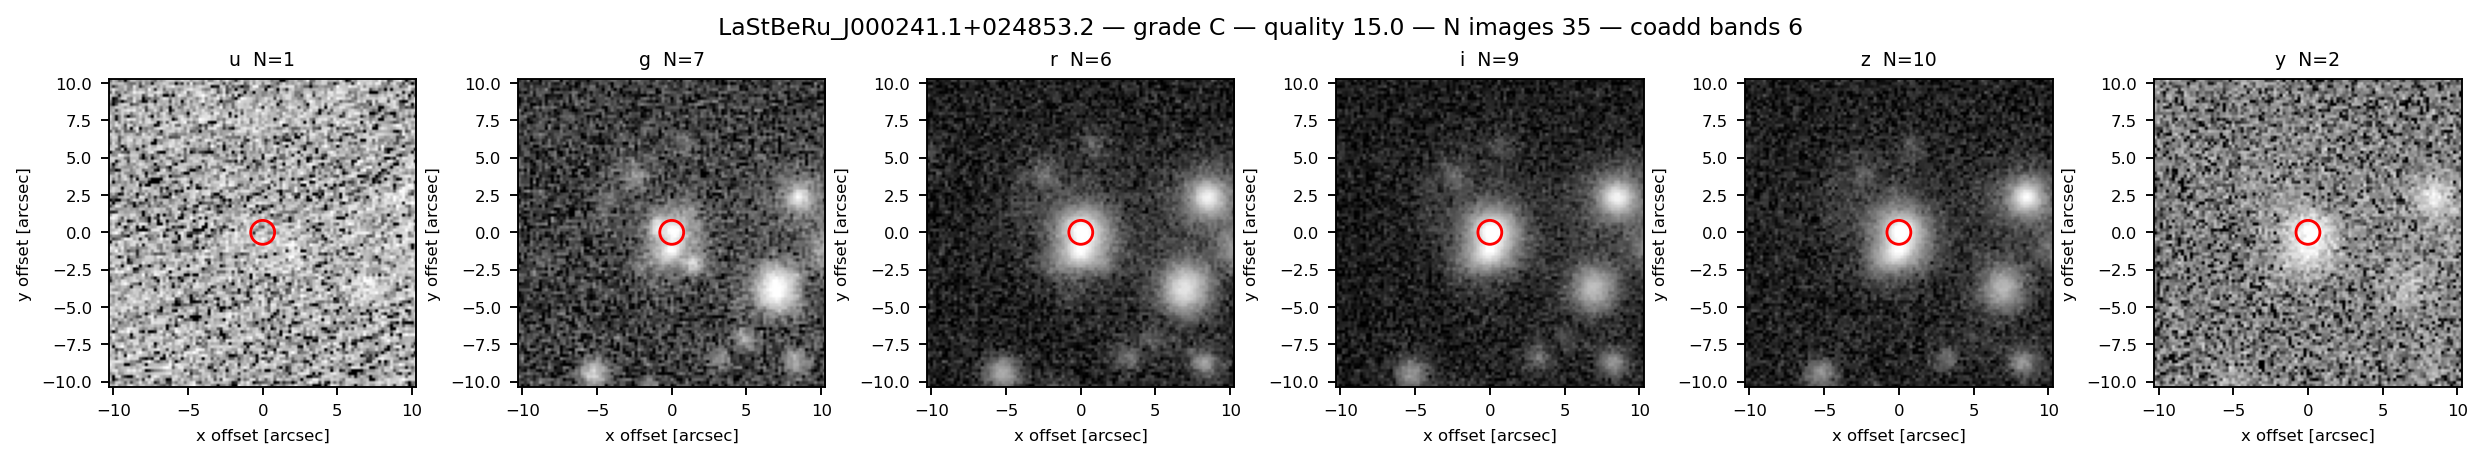

In [6]:
if RUN_CUTOUTS:
    if "cutout_selected" not in catalog:
        raise RuntimeError("Run the direct coadd stage first so cutout candidates are ranked.")
    catalog = generate_reference_catalog_cutouts(
        config, catalog, reuse_existing=not REGENERATE_CUTOUTS
    )

if "cutout_status" in catalog:
    display(catalog["cutout_status"].value_counts(dropna=False).rename_axis("status").to_frame("targets"))
    generated = catalog.loc[catalog["cutout_status"].isin(["generated", "reused"])].sort_values("cutout_priority_rank")
    for row in generated.head(MAX_CUTOUTS).itertuples(index=False):
        print(f"Rank {int(row.cutout_priority_rank)} — {row.target_id}")
        display(Image(filename=row.cutout_path))